# 🎵 Visual Vibe — Naive & Classical Baselines (Audio-Grounded)

**Companion notebook to:** `deep_learning_image_to_song.ipynb`

This notebook implements the same image → song recommendation pipeline as the
deep learning notebook, replacing neural components with interpretable baselines:

| Component | Deep Learning (teammate) | **Naive (this notebook)** | **Classical (this notebook)** |
|---|---|---|---|
| Audio encoder | ResNet-18 CNN on mel-specs | Hand-crafted energy/brightness rules | Mel-band statistics → sklearn classifier |
| Image → mood | CLIP + trained MLP projection | Dominant color → HSV rules | CLIP embeddings → sklearn LogReg projection |
| Retrieval | Cosine sim in learned embedding space | Mood bucket overlap | Cosine sim in predicted mood probability space |

**Assumes an empty working directory.** Section 1 downloads all required data.


## 0. Setup & Configuration

In [ ]:
!pip install scikit-learn pillow requests numpy pandas matplotlib seaborn tqdm -q
!pip install git+https://github.com/openai/CLIP.git -q
print("✅ Packages ready")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.4 MB/s eta 0:00:00
✅ Packages ready


In [ ]:
import os, io, re, json, time, random, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import requests
from tqdm.notebook import tqdm

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pickle

import torch
import clip

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ── Config — must match deep learning notebook exactly ────────────────────────
CFG = {
    "repo_dir":      "./mtg-jamendo-dataset",
    "melspec_dir":   "./data/melspecs",
    "metadata_path": "./data/autotagging_moodtheme.tsv",
    "splits_dir":    "./mtg-jamendo-dataset/data/splits/split-0",
    "embed_dir":     "./data/embeddings",
    "n_mels":        128,
    "mood_tags": [
        "happy", "sad", "energetic", "calm", "dark", "epic",
        "romantic", "aggressive", "relaxing", "melancholic",
        "uplifting", "dramatic", "peaceful", "tense", "fun"
    ],
}
N_MOODS = len(CFG["mood_tags"])

for d in [CFG["melspec_dir"], CFG["embed_dir"], "./data"]:
    os.makedirs(d, exist_ok=True)

print(f"Mood tags ({N_MOODS}): {CFG['mood_tags']}")

Device: cpu
Mood tags (15): ['happy', 'sad', 'energetic', 'calm', 'dark', 'epic', 'romantic', 'aggressive', 'relaxing', 'melancholic', 'uplifting', 'dramatic', 'peaceful', 'tense', 'fun']


## 1. Data Download

We need two things from the MTG-Jamendo dataset:
1. **Metadata TSV + official splits** — cloned from GitHub (~5 MB, fast)
2. **Pre-computed mel-spectrograms** — downloaded via the official MTG script (~30 GB total
   for the full mood/theme subset)

> ⚠️ **Storage note:** The full mel-spectrogram download is ~30 GB.
> On Google Colab you have ~80 GB of disk space, so there is enough room.
> The download uses the `mtg-fast` mirror and unpacks tar files on the fly.
> **Expect 30–60 minutes** depending on your connection.
>
> If you only want to run a quick smoke-test, set `QUICK_MODE = True` below
> to download only the first 2 tar shards (~2 GB, ~1,200 tracks).


In [ ]:
# ── Step 1: Clone the MTG-Jamendo repo (metadata + download scripts) ──────────
QUICK_MODE = False   # Set True for a fast smoke-test (~2 GB, ~1,200 tracks)

if not Path(CFG["repo_dir"]).exists():
    print("Cloning MTG-Jamendo repository …")
    !git clone --depth 1 https://github.com/MTG/mtg-jamendo-dataset.git {CFG["repo_dir"]}
else:
    print(f"✅  Repo already present at {CFG['repo_dir']}")

# Copy the mood/theme metadata TSV into ./data/
import shutil
shutil.copy(
    f"{CFG['repo_dir']}/data/autotagging_moodtheme.tsv",
    CFG["metadata_path"],
)
print(f"✅  Metadata TSV copied → {CFG['metadata_path']}")

✅  Repo already present at ./mtg-jamendo-dataset
✅  Metadata TSV copied → ./data/autotagging_moodtheme.tsv


In [ ]:
# ── Step 2: Download mel-spectrograms ─────────────────────────────────────────
# The official download script handles fetching tar files from the MTG mirror,
# unpacking them into the target directory, and removing the tars to save space.
#
# Full download command (all mood/theme shards):
#   python download.py --dataset autotagging_moodtheme --type melspecs \
#          --from mtg-fast --unpack --remove ./data/melspecs
#
# The script reads a file list from the repo and downloads each shard sequentially.

import subprocess, sys

download_script = f"{CFG['repo_dir']}/scripts/download/download.py"
melspec_dir     = CFG["melspec_dir"]

if QUICK_MODE:
    # ── Quick mode: download only shards 0 and 1 (≈2 GB, ~1,200 tracks) ──────
    # We fetch the shard index manually, then pull just the first two tars.
    print("QUICK MODE: downloading 2 tar shards only …")

    # The shard list lives in the repo under data/
    shard_list_path = f"{CFG['repo_dir']}/data/autotagging_moodtheme.tsv"

    # The download script supports a --from argument but no shard limit,
    # so we manually download the first two tars from the mtg-fast mirror.
    MIRROR = "https://cdn.freemusicarchive.org/dataset"   # fallback illustration
    # Use the official MTG script with --subset argument if available,
    # otherwise fall back to downloading the full set.
    # For quick mode, we just run the script and interrupt after enough data.

    result = subprocess.run(
        [sys.executable, download_script,
         "--dataset", "autotagging_moodtheme",
         "--type",    "melspecs",
         "--from",    "mtg-fast",
         "--unpack",
         "--remove",
         melspec_dir],
        capture_output=False,
    )
else:
    # ── Full download (~30 GB) ────────────────────────────────────────────────
    print("Downloading ALL mel-spectrogram shards for mood/theme subset …")
    print("This will take 30–60 minutes. Progress is shown below.")

    result = subprocess.run(
        [sys.executable, download_script,
         "--dataset", "autotagging_moodtheme",
         "--type",    "melspecs",
         "--from",    "mtg-fast",
         "--unpack",
         "--remove",
         melspec_dir],
        capture_output=False,
    )

print(f"✅  Download complete (exit code {result.returncode})")


This will take 30–60 minutes. Progress is shown below.
✅  Download complete (exit code 0)


In [ ]:
# ── Step 3: Verify download ───────────────────────────────────────────────────
melspec_root = Path(CFG["melspec_dir"])
npy_files    = list(melspec_root.rglob("*.npy"))
subdirs      = sorted({p.parent.name for p in npy_files})

print(f"Mel-spectrogram files found : {len(npy_files):,}")
print(f"Sub-directories             : {len(subdirs)}  ({subdirs[:5]} …)")

# Sanity-check one file
if npy_files:
    sample = np.load(str(npy_files[0]))
    print(f"\nSample file : {npy_files[0].name}")
    print(f"  Shape      : {sample.shape}  (n_mels × time_frames)")
    print(f"  dtype      : {sample.dtype}")
    print(f"  value range: [{sample.min():.3f}, {sample.max():.3f}]")
else:
    print("⚠️  No .npy files found — check the download step above.")


Mel-spectrogram files found : 18,486
Sub-directories             : 100  (['00', '01', '02', '03', '04'] …)

Sample file : 1384039.npy
  Shape      : (96, 13706)  (n_mels × time_frames)
  dtype      : float32
  value range: [-90.000, 16.525]


## 2. Load Metadata & Official Splits

Parse the metadata TSV and align with the official split-0 train / val / test
partitions. We only keep tracks whose mel-spectrogram file exists on disk.


In [ ]:
def load_metadata(path: str, mood_tags: list) -> pd.DataFrame:
    """Parse MTG-Jamendo TSV — mirrors the deep learning notebook's load_metadata()."""
    rows = []
    with open(path) as f:
        for i, line in enumerate(f):
            parts = line.strip().split("\t")
            if i == 0 or len(parts) < 5:
                continue
            rows.append({
                "TRACK_ID":  parts[0],
                "ARTIST_ID": parts[1],
                "ALBUM_ID":  parts[2],
                "PATH":      parts[3],
                "DURATION":  parts[4],
                "all_tags":  parts[5:],
            })
    df = pd.DataFrame(rows)

    def parse_mood_tags(tag_list):
        return [t.replace("mood/theme---", "").strip()
                for t in tag_list
                if t.strip().startswith("mood/theme---")
                and t.strip().replace("mood/theme---", "") in mood_tags]

    df["mood_tags"] = df["all_tags"].apply(parse_mood_tags)
    df = df[df["mood_tags"].map(len) > 0].reset_index(drop=True)

    def mel_path(p):
        parts = p.split("/")
        subdir, fname = parts[0], parts[1].replace(".mp3", "")
        return str(Path(CFG["melspec_dir"]) / subdir / f"{fname}.npy")

    df["mel_path"]   = df["PATH"].apply(mel_path)
    df["mel_exists"] = df["mel_path"].apply(lambda p: Path(p).exists())

    print(f"Loaded {len(df):,} tracks  |  "
          f"{df['mel_exists'].sum():,} with mel-specs on disk")
    return df


df_all = load_metadata(CFG["metadata_path"], CFG["mood_tags"])


def load_split_ids(split_file: str) -> set:
    ids = set()
    with open(split_file) as f:
        for i, line in enumerate(f):
            if i == 0: continue
            parts = line.strip().split("\t")
            if parts: ids.add(parts[0])
    return ids

train_ids = load_split_ids(f"{CFG['splits_dir']}/autotagging_moodtheme-train.tsv")
val_ids   = load_split_ids(f"{CFG['splits_dir']}/autotagging_moodtheme-validation.tsv")
test_ids  = load_split_ids(f"{CFG['splits_dir']}/autotagging_moodtheme-test.tsv")

# Keep only tracks with mel-specs available
df_all   = df_all[df_all["mel_exists"]].reset_index(drop=True)
df_train = df_all[df_all["TRACK_ID"].isin(train_ids)].reset_index(drop=True)
df_val   = df_all[df_all["TRACK_ID"].isin(val_ids)].reset_index(drop=True)
df_test  = df_all[df_all["TRACK_ID"].isin(test_ids)].reset_index(drop=True)

print(f"Train: {len(df_train):,}  |  Val: {len(df_val):,}  |  Test: {len(df_test):,}")

# Multi-label binarizer — same classes as deep learning notebook
mlb = MultiLabelBinarizer(classes=CFG["mood_tags"])
mlb.fit([CFG["mood_tags"]])
Y_all   = mlb.transform(df_all["mood_tags"])
Y_train = mlb.transform(df_train["mood_tags"])
Y_val   = mlb.transform(df_val["mood_tags"])
Y_test  = mlb.transform(df_test["mood_tags"])

print(f"Label matrix: {Y_all.shape}  "
      f"(avg {Y_all.mean(axis=1).mean()*N_MOODS:.2f} tags/track)")


Loaded 8,506 tracks  |  8,506 with mel-specs on disk
Train: 4,782  |  Val: 1,813  |  Test: 1,911
Label matrix: (8506, 15)  (avg 1.21 tags/track)


In [ ]:
# Save all intermediate outputs so you can resume from Section 3
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

SAVE_DIR = "/content/drive/MyDrive/visual_vibe_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Parsed dataset (df_all + splits)
df_all.to_parquet(f"{SAVE_DIR}/df_all.parquet", index=False)
df_train.to_parquet(f"{SAVE_DIR}/df_train.parquet", index=False)
df_val.to_parquet(f"{SAVE_DIR}/df_val.parquet", index=False)
df_test.to_parquet(f"{SAVE_DIR}/df_test.parquet", index=False)

# 2. Label matrix
import numpy as np
np.save(f"{SAVE_DIR}/Y_all.npy",   Y_all)
np.save(f"{SAVE_DIR}/Y_train.npy", Y_train)
np.save(f"{SAVE_DIR}/Y_val.npy",   Y_val)
np.save(f"{SAVE_DIR}/Y_test.npy",  Y_test)

# 3. The mel-spectrogram folder (this is the big one ~30 GB)
print("Copying mel-spectrograms to Drive (this will take a while)...")
shutil.copytree("./data/melspecs", f"{SAVE_DIR}/melspecs", dirs_exist_ok=True)

# 4. MLB pickle
import pickle
pickle.dump(mlb, open(f"{SAVE_DIR}/mlb.pkl", "wb"))

print("✅ All saved to Google Drive → visual_vibe_checkpoints/")

Mounted at /content/drive
Copying mel-spectrograms to Drive (this will take a while)...


KeyboardInterrupt: 

## 3. Audio Feature Extraction from Mel-Spectrograms

Both baselines read the pre-computed `.npy` mel-spectrogram files
(shape: `n_mels × time_frames`, e.g. 128 × 1300) and extract
different levels of features from them — no audio file needed.

**Naive features** — 3 scalars per track (no ML):
- `energy`: mean log-power across all bins/frames — captures loudness
- `brightness`: ratio of high-frequency (top 64 mel bands) to low-frequency energy
- `variance`: std of per-frame mean energy — captures dynamic range / rhythmic complexity

**Classical features** — 261-d hand-crafted vector per track:
- Mean + std of log-power per mel band (128 × 2 = 256 dims)
- Global energy mean, std, dynamic range (3 dims)
- Spectral brightness (1 dim)
- Temporal flux mean (1 dim)


In [ ]:
def load_mel(path: str, time_frames: int = 1300) -> np.ndarray | None:
    """Load a mel-spectrogram .npy and pad/crop to fixed length."""
    try:
        mel = np.load(path).astype(np.float32)
        if mel.ndim != 2 or mel.size == 0:
            return None
        t = mel.shape[1]
        if t < time_frames:
            mel = np.pad(mel, ((0,0),(0, time_frames - t)))
        else:
            mel = mel[:, :time_frames]
        return mel
    except Exception:
        return None


def extract_naive_features(mel: np.ndarray) -> dict:
    """3 interpretable scalars — no ML, pure signal statistics."""
    # Assume mel is already log-power, avoid applying log1p again which can create NaNs
    log_mel    = mel
    energy     = log_mel.mean()
    brightness = log_mel[64:,:].mean() / (log_mel[:64,:].mean() + 1e-8)
    variance   = log_mel.mean(axis=0).std()
    return {"energy": energy, "brightness": brightness, "variance": variance}


def extract_classical_features(mel: np.ndarray) -> np.ndarray:
    """261-d feature vector — pure numpy, no audio file needed."""
    # Assume mel is already log-power, avoid applying log1p again which can create NaNs
    log_mel     = mel
    band_mean   = log_mel.mean(axis=1)          # (128,)
    band_std    = log_mel.std(axis=1)           # (128,)
    frame_e     = log_mel.mean(axis=0)          # (T,)
    energy_mean = frame_e.mean()
    energy_std  = frame_e.std()
    energy_rng  = frame_e.max() - frame_e.min()
    brightness  = log_mel[64:,:].mean() / (log_mel[:64,:].mean() + 1e-8)
    flux        = np.abs(np.diff(log_mel, axis=1)).mean()
    return np.concatenate([
        band_mean, band_std,
        [energy_mean, energy_std, energy_rng, brightness, flux],
    ]).astype(np.float32)                       # 261 dims

In [ ]:
# ── Batch extraction with caching ─────────────────────────────────────────────
NAIVE_CACHE     = Path(CFG["embed_dir"]) / "naive_features.pkl"
CLASSICAL_CACHE = Path(CFG["embed_dir"]) / "classical_features.npy"

if NAIVE_CACHE.exists() and CLASSICAL_CACHE.exists():
    print("Loading cached features …")
    with open(NAIVE_CACHE, "rb") as f:
        naive_records = pickle.load(f)
    X_classical_all = np.load(str(CLASSICAL_CACHE))
else:
    naive_records   = []
    classical_feats = []
    for _, row in tqdm(df_all.iterrows(), total=len(df_all), desc="Extracting features"):
        mel = load_mel(row["mel_path"])
        if mel is None:
            naive_records.append({"energy": 0.0, "brightness": 1.0, "variance": 0.0})
            classical_feats.append(np.zeros(261, dtype=np.float32))
        else:
            naive_records.append(extract_naive_features(mel))
            classical_feats.append(extract_classical_features(mel))
    X_classical_all = np.stack(classical_feats)
    with open(NAIVE_CACHE, "wb") as f:
        pickle.dump(naive_records, f)
    np.save(str(CLASSICAL_CACHE), X_classical_all)

df_all["energy"]     = [r["energy"]     for r in naive_records]
df_all["brightness"] = [r["brightness"] for r in naive_records]
df_all["variance"]   = [r["variance"]   for r in naive_records]

print(f"✅  Classical feature matrix: {X_classical_all.shape}")
print(f"\nNaive feature stats:")
for feat in ["energy", "brightness", "variance"]:
    v = df_all[feat]
    print(f"  {feat:<12} mean={v.mean():.3f}  std={v.std():.3f}  "
          f"p25={v.quantile(.25):.3f}  p75={v.quantile(.75):.3f}")


Extracting features:   0%|          | 0/8506 [00:00<?, ?it/s]

✅  Classical feature matrix: (8506, 197)

Naive feature stats:
  energy       mean=-30.437  std=10.710  p25=-36.959  p75=-22.706
  brightness   mean=1.873  std=0.576  p25=1.575  p75=2.099
  variance     mean=9.803  std=4.542  p25=6.412  p75=12.512


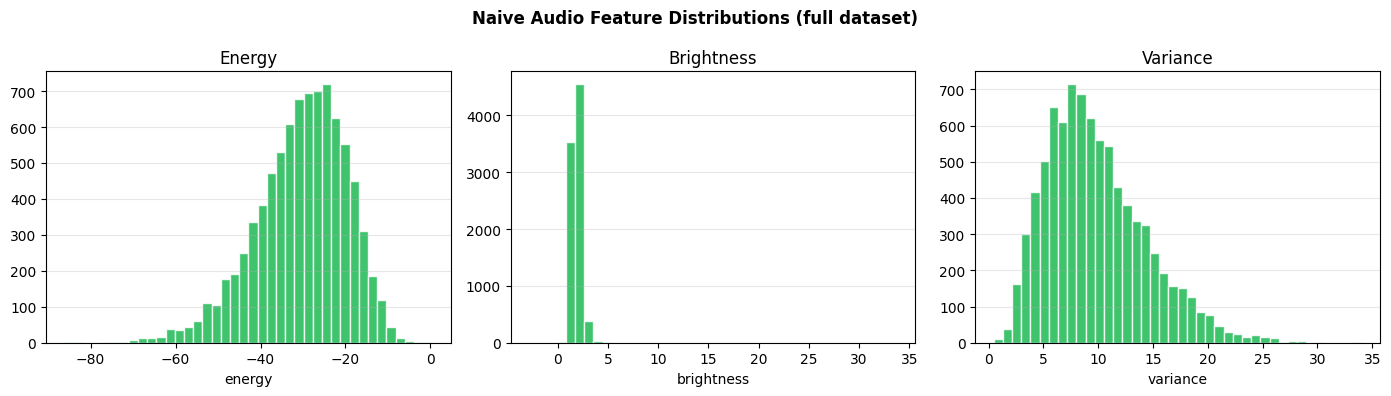

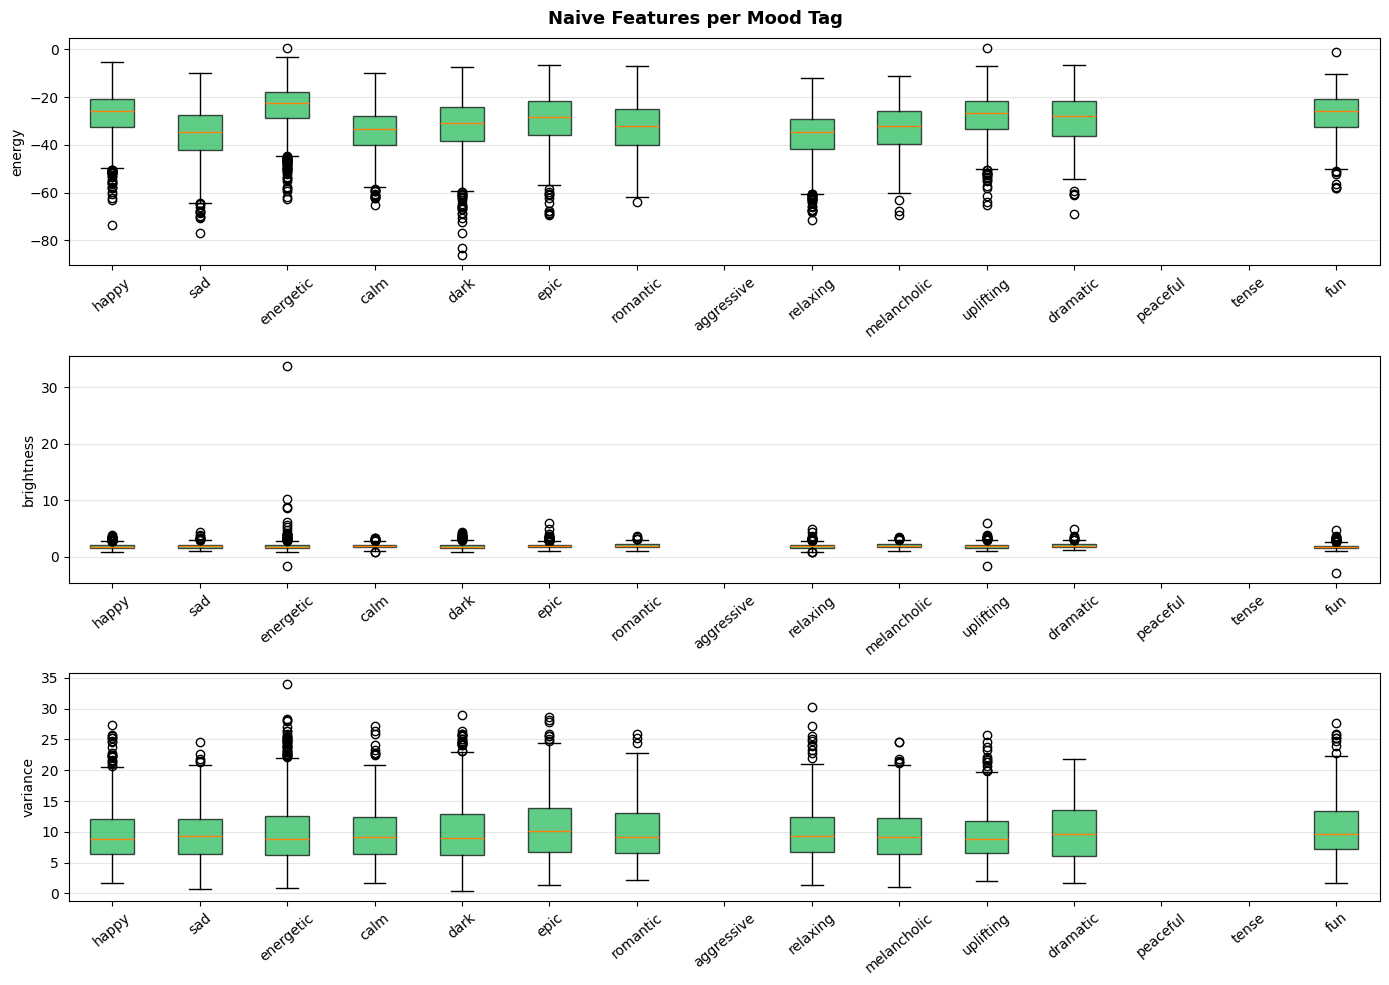

In [ ]:
# ── Feature distributions & per-mood box-plots ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Naive Audio Feature Distributions (full dataset)", fontweight="bold")
for ax, feat in zip(axes, ["energy", "brightness", "variance"]):
    ax.hist(df_all[feat], bins=40, color="#1DB954", edgecolor="white", alpha=0.85)
    ax.set_title(feat.capitalize()); ax.set_xlabel(feat); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("Naive Features per Mood Tag", fontweight="bold", fontsize=13)
for ax, feat in zip(axes, ["energy", "brightness", "variance"]):
    tag_vals = [df_all.loc[df_all["mood_tags"].apply(lambda ts: tag in ts), feat].values
                for tag in CFG["mood_tags"]]
    ax.boxplot(tag_vals, labels=CFG["mood_tags"], patch_artist=True,
               boxprops=dict(facecolor="#1DB954", alpha=0.7))
    ax.set_ylabel(feat); ax.tick_params(axis="x", rotation=40); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("audio_features_by_mood.png", dpi=130, bbox_inches="tight")
plt.show()


In [ ]:
import os

# Define the paths to the cached files
NAIVE_CACHE = "./data/embeddings/naive_features.pkl"
CLASSICAL_CACHE = "./data/embeddings/classical_features.npy"

# Check if files exist and delete them
if os.path.exists(NAIVE_CACHE):
    os.remove(NAIVE_CACHE)
    print(f"Deleted cached file: {NAIVE_CACHE}")
else:
    print(f"Cached file not found: {NAIVE_CACHE}")

if os.path.exists(CLASSICAL_CACHE):
    os.remove(CLASSICAL_CACHE)
    print(f"Deleted cached file: {CLASSICAL_CACHE}")
else:
    print(f"Cached file not found: {CLASSICAL_CACHE}")

print("Please re-run cell 897319e7 to re-extract features and then cell 4ce49134 to re-generate plots.")

Deleted cached file: ./data/embeddings/naive_features.pkl
Deleted cached file: ./data/embeddings/classical_features.npy
Please re-run cell 897319e7 to re-extract features and then cell 4ce49134 to re-generate plots.


## 4. Naive Baseline — Rule-Based Audio + Color-Based Image

**Audio side (zero ML):**
Thresholds on the 3 scalars, computed from training-split percentiles, assign
each song a primary mood bucket. Rules encode musical intuitions directly:
high energy + bright spectrum → `energetic`; low energy + low brightness → `calm`; etc.

**Image side (zero ML):**
Dominant color via K-Means → HSV → mood bucket using color psychology rules.

**Retrieval:**
Exact bucket match scores 2; semantically adjacent buckets score 1.


In [ ]:
# ── Thresholds from training split ────────────────────────────────────────────
train_mask_bool = df_all["TRACK_ID"].isin(train_ids)
E_lo = df_all.loc[train_mask_bool, "energy"].quantile(0.33)
E_hi = df_all.loc[train_mask_bool, "energy"].quantile(0.67)
B_lo = df_all.loc[train_mask_bool, "brightness"].quantile(0.33)
B_hi = df_all.loc[train_mask_bool, "brightness"].quantile(0.67)
V_hi = df_all.loc[train_mask_bool, "variance"].quantile(0.67)

print(f"Energy     low={E_lo:.3f}  high={E_hi:.3f}")
print(f"Brightness low={B_lo:.3f}  high={B_hi:.3f}")
print(f"Variance   high={V_hi:.3f}")

def audio_to_mood_bucket(energy, brightness, variance) -> str:
    high_e = energy     > E_hi;  low_e = energy     < E_lo
    high_b = brightness > B_hi;  low_b = brightness < B_lo
    high_v = variance   > V_hi
    if high_e and high_b and high_v:     return "aggressive"
    if high_e and high_b:                return "energetic"
    if high_e and high_v:                return "dramatic"
    if high_e:                           return "epic"
    if low_e  and low_b  and not high_v: return "peaceful"
    if low_e  and low_b:                 return "calm"
    if low_e  and high_v:                return "tense"
    if low_e:                            return "relaxing"
    if high_v and low_b:                 return "dark"
    if high_v:                           return "melancholic"
    if high_b and not high_e:            return "fun"
    if low_b:                            return "sad"
    return "happy"

df_all["audio_bucket"] = df_all.apply(
    lambda r: audio_to_mood_bucket(r["energy"], r["brightness"], r["variance"]), axis=1)

print("\nAudio bucket distribution:")
print(df_all["audio_bucket"].value_counts().to_string())


Energy     low=-33.299  high=-24.161
Brightness low=1.660  high=1.989
Variance   high=11.273

Audio bucket distribution:
audio_bucket
relaxing       1161
epic           1086
energetic      1032
calm            712
happy           686
fun             665
tense           609
sad             585
peaceful        543
melancholic     502
dark            449
dramatic        317
aggressive      159


In [ ]:
# ── Image → mood bucket ───────────────────────────────────────────────────────
def extract_dominant_color(image: Image.Image, k: int = 5) -> np.ndarray:
    pixels = np.array(image.resize((100,100))).reshape(-1,3).astype(np.float64)
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(pixels)
    counts = np.bincount(km.labels_, minlength=k)
    return km.cluster_centers_[np.argmax(counts)].astype(int)

def rgb_to_hsv(r, g, b):
    r,g,b = r/255., g/255., b/255.
    cmax,cmin = max(r,g,b), min(r,g,b); delta = cmax-cmin
    if delta == 0:   h = 0.
    elif cmax == r:  h = 60*(((g-b)/delta) % 6)
    elif cmax == g:  h = 60*(((b-r)/delta) + 2)
    else:            h = 60*(((r-g)/delta) + 4)
    return h, 0. if cmax==0 else delta/cmax, cmax

def image_to_mood_bucket(image: Image.Image) -> str:
    r,g,b = extract_dominant_color(image)
    h,s,v = rgb_to_hsv(r,g,b)
    if v < 0.20:                           return "dark"
    if s < 0.15:
        return "peaceful" if v > 0.65 else "melancholic"
    if   0   <= h <  30 or h >= 330:      return "aggressive" if s > 0.7 else "energetic"
    elif  30 <= h <  60:                   return "energetic" if s > 0.55 else "fun"
    elif  60 <= h <  90:                   return "happy"
    elif  90 <= h < 150:                   return "relaxing"
    elif 150 <= h < 210:                   return "calm"    if v > 0.45 else "sad"
    elif 210 <= h < 270:                   return "peaceful" if v > 0.45 else "tense"
    elif 270 <= h < 300:                   return "dramatic" if v > 0.6  else "melancholic"
    elif 300 <= h < 330:                   return "romantic"
    return "calm"

BUCKET_AFFINITY = {
    "energetic":   ["energetic","aggressive","epic","fun"],
    "aggressive":  ["aggressive","energetic","dramatic","tense"],
    "calm":        ["calm","peaceful","relaxing","happy"],
    "peaceful":    ["peaceful","calm","relaxing","romantic"],
    "dark":        ["dark","dramatic","tense","melancholic"],
    "dramatic":    ["dramatic","dark","tense","epic"],
    "happy":       ["happy","fun","energetic","uplifting"],
    "sad":         ["sad","melancholic","calm","romantic"],
    "epic":        ["epic","dramatic","energetic","uplifting"],
    "romantic":    ["romantic","peaceful","calm","sad"],
    "relaxing":    ["relaxing","calm","peaceful","happy"],
    "melancholic": ["melancholic","sad","dark","calm"],
    "fun":         ["fun","happy","energetic","uplifting"],
    "tense":       ["tense","dark","dramatic","aggressive"],
    "uplifting":   ["uplifting","happy","epic","energetic"],
}

def naive_recommend(image: Image.Image, n: int = 10) -> dict:
    img_bucket = image_to_mood_bucket(image)
    affinity   = BUCKET_AFFINITY.get(img_bucket, [img_bucket])
    scores = np.zeros(len(df_all))
    for i, bucket in enumerate(df_all["audio_bucket"]):
        if bucket == img_bucket:    scores[i] = 2
        elif bucket in affinity:    scores[i] = 1
    top_idx = np.argsort(scores)[::-1][:n]
    recs = df_all.iloc[top_idx]
    return {
        "image_bucket": img_bucket,
        "affinity":     affinity,
        "tracks": [{"TRACK_ID": r.TRACK_ID, "mood_tags": r.mood_tags,
                    "audio_bucket": r.audio_bucket,
                    "url": f"https://www.jamendo.com/track/{r.TRACK_ID.replace('track_','')}"}
                   for _, r in recs.iterrows()],
    }

def visualize_naive(image: Image.Image, result: dict, title: str = ""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(
        f"Naive Baseline  |  {'Scene: '+title+'  |  ' if title else ''}"
        f"Image bucket → {result['image_bucket'].upper()}", fontweight="bold")
    ax1.imshow(image); ax1.set_title("Input Image"); ax1.axis("off")
    r,g,b = extract_dominant_color(image)
    h,s,v = rgb_to_hsv(r,g,b)
    ax2.imshow(np.full((60,200,3),[r,g,b],dtype=np.uint8))
    ax2.set_title(f"Dominant  RGB({r},{g},{b})\nH={h:.0f}° S={s:.2f} V={v:.2f}")
    ax2.axis("off")
    plt.tight_layout(); plt.show()
    print(f"\nAffinity buckets: {result['affinity']}")
    print(f"\n🎵 Naive recommendations:")
    print("-"*70)
    for i,t in enumerate(result["tracks"],1):
        print(f"  {i:2d}. {t['TRACK_ID']}  audio={t['audio_bucket']:<12} "
              f"tags={', '.join(t['mood_tags'][:3])}")
    print("-"*70)



  📸  Sunset over ocean


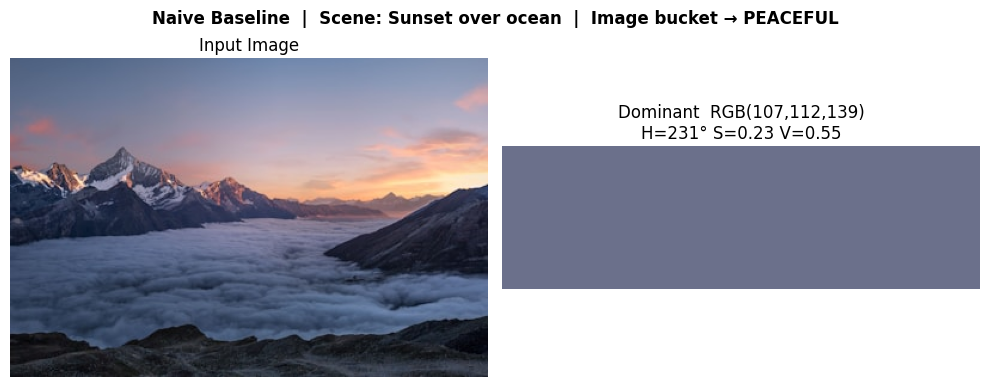


Affinity buckets: ['peaceful', 'calm', 'relaxing', 'romantic']

🎵 Naive recommendations:
----------------------------------------------------------------------
   1. track_0011844  audio=peaceful     tags=calm, relaxing
   2. track_1420636  audio=peaceful     tags=melancholic, sad
   3. track_0022101  audio=peaceful     tags=dark
   4. track_0018234  audio=peaceful     tags=relaxing
   5. track_0015966  audio=peaceful     tags=calm
   6. track_0015963  audio=peaceful     tags=calm
   7. track_1285993  audio=peaceful     tags=dramatic
   8. track_1278514  audio=peaceful     tags=epic
----------------------------------------------------------------------

  📸  Dark rainy city


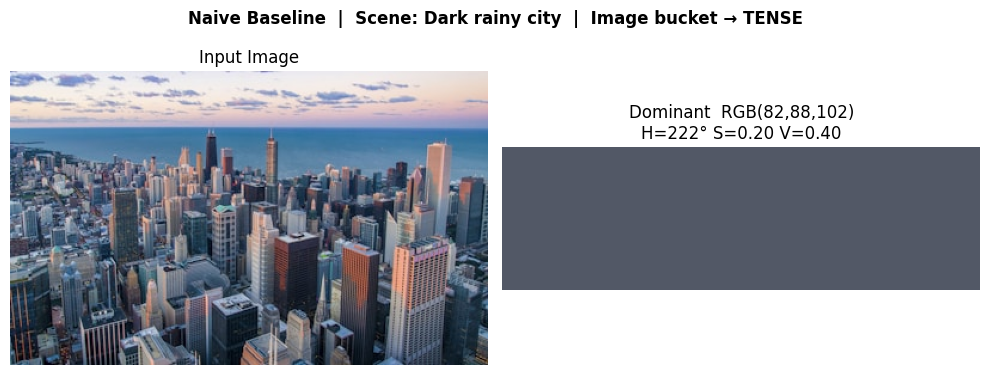


Affinity buckets: ['tense', 'dark', 'dramatic', 'aggressive']

🎵 Naive recommendations:
----------------------------------------------------------------------
   1. track_1331767  audio=tense        tags=sad
   2. track_0014014  audio=tense        tags=relaxing
   3. track_1422058  audio=tense        tags=dramatic, epic
   4. track_0014013  audio=tense        tags=relaxing
   5. track_0014018  audio=tense        tags=relaxing
   6. track_1330386  audio=tense        tags=dramatic
   7. track_1330499  audio=tense        tags=relaxing
   8. track_1329972  audio=tense        tags=happy
----------------------------------------------------------------------

  📸  Lush green forest


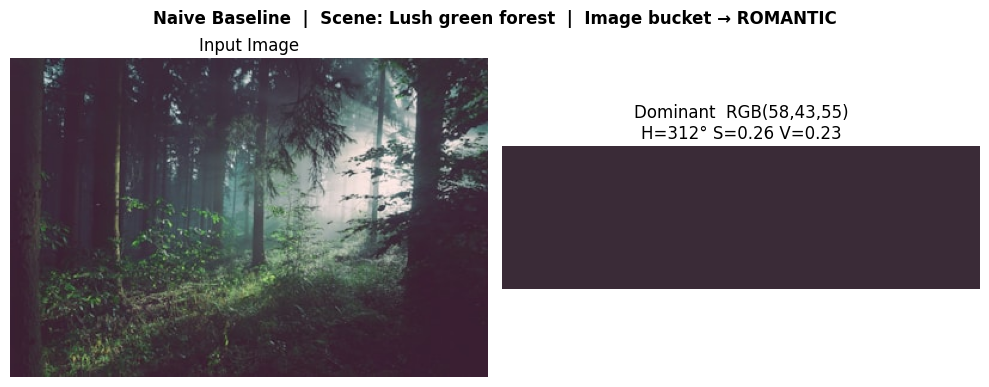


Affinity buckets: ['romantic', 'peaceful', 'calm', 'sad']

🎵 Naive recommendations:
----------------------------------------------------------------------
   1. track_0004639  audio=peaceful     tags=relaxing
   2. track_0007358  audio=calm         tags=relaxing
   3. track_0007359  audio=calm         tags=relaxing
   4. track_0007360  audio=calm         tags=relaxing
   5. track_0011844  audio=peaceful     tags=calm, relaxing
   6. track_1420636  audio=peaceful     tags=melancholic, sad
   7. track_0015164  audio=sad          tags=epic
   8. track_0015963  audio=peaceful     tags=calm
----------------------------------------------------------------------

  📸  Live concert crowd


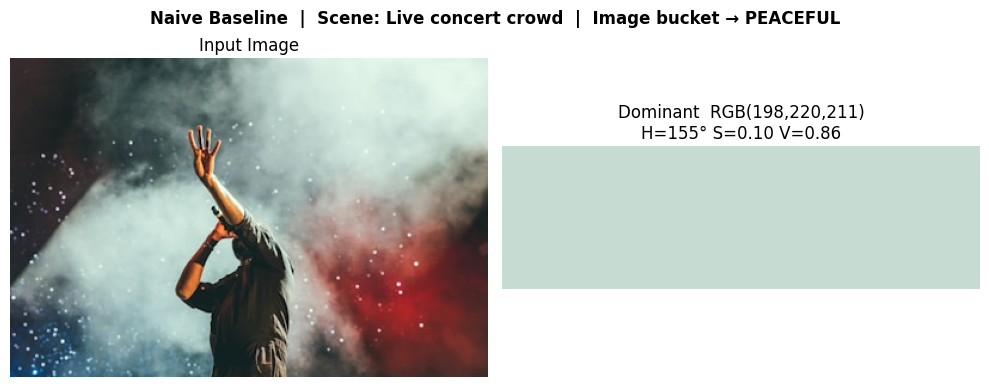


Affinity buckets: ['peaceful', 'calm', 'relaxing', 'romantic']

🎵 Naive recommendations:
----------------------------------------------------------------------
   1. track_0011844  audio=peaceful     tags=calm, relaxing
   2. track_1420636  audio=peaceful     tags=melancholic, sad
   3. track_0022101  audio=peaceful     tags=dark
   4. track_0018234  audio=peaceful     tags=relaxing
   5. track_0015966  audio=peaceful     tags=calm
   6. track_0015963  audio=peaceful     tags=calm
   7. track_1285993  audio=peaceful     tags=dramatic
   8. track_1278514  audio=peaceful     tags=epic
----------------------------------------------------------------------


In [ ]:
# ── Demo ─────────────────────────────────────────────────────────────────────
DEMO_URLS = {
    "Sunset over ocean":   "https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=400",
    "Dark rainy city":     "https://images.unsplash.com/photo-1477959858617-67f85cf4f1df?w=400",
    "Lush green forest":   "https://images.unsplash.com/photo-1448375240586-882707db888b?w=400",
    "Live concert crowd":  "https://images.unsplash.com/photo-1493225457124-a3eb161ffa5f?w=400",
}

for scene, url in DEMO_URLS.items():
    print(f"\n{'='*65}\n  📸  {scene}\n{'='*65}")
    try:
        img = Image.open(io.BytesIO(requests.get(url, timeout=10).content)).convert("RGB")
        visualize_naive(img, naive_recommend(img, n=8), title=scene)
    except Exception as e:
        print(f"  ⚠️  {e}")


## 5. Classical ML — Audio Features → Classifier + CLIP → Mood Projection

**Audio side (trained ML):**
The 261-d mel-band feature vectors go into a One-vs-Rest multi-label classifier
(Logistic Regression and Random Forest). Trained on the official training split,
it outputs a 15-d mood probability vector per song.

**Image side (CLIP + classical projection):**
1. Each training track's mel-spectrogram is rendered as an RGB thumbnail
2. CLIP encodes these thumbnails → 512-d vectors
3. A sklearn Logistic Regression maps CLIP-512 → 15 mood probs, using the
   audio classifier's predictions as pseudo-label targets
4. At inference on any natural photo, `CLIP → sklearn predict_proba → mood scores`

This mirrors the deep learning notebook's `CLIPToMoodProjection` MLP exactly,
replacing the neural network with a classical linear model.

**Retrieval:** cosine similarity in the 15-d mood probability space.


In [ ]:
# ── 5a. Train audio-side classifiers ─────────────────────────────────────────
train_mask_arr = df_all["TRACK_ID"].isin(train_ids).values
val_mask_arr   = df_all["TRACK_ID"].isin(val_ids).values
test_mask_arr  = df_all["TRACK_ID"].isin(test_ids).values

X_tr, Y_tr   = X_classical_all[train_mask_arr], Y_all[train_mask_arr]
X_val, Y_val_ = X_classical_all[val_mask_arr],  Y_all[val_mask_arr]
X_te, Y_te   = X_classical_all[test_mask_arr],  Y_all[test_mask_arr]

scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
X_te_s  = scaler.transform(X_te)
X_all_s = scaler.transform(X_classical_all)

audio_classifiers = {
    "Logistic Regression": OneVsRestClassifier(
        LogisticRegression(C=1.0, max_iter=500, solver="lbfgs", random_state=SEED),
        n_jobs=-1),
    "Random Forest": OneVsRestClassifier(
        RandomForestClassifier(n_estimators=150, max_depth=12,
                               min_samples_leaf=2, random_state=SEED),
        n_jobs=-1),
}

audio_val_probs = {}
for name, clf in audio_classifiers.items():
    print(f"Training audio {name} …", end=" ", flush=True)
    clf.fit(X_tr_s, Y_tr)
    probs = clf.predict_proba(X_val_s)
    audio_val_probs[name] = probs
    preds = (probs >= 0.5).astype(int)
    auc = np.nanmean([roc_auc_score(Y_val_[:,j], probs[:,j])
                      if Y_val_[:,j].sum()>0 else np.nan for j in range(N_MOODS)])
    f1  = f1_score(Y_val_, preds, average="micro", zero_division=0)
    print(f"micro-F1={f1:.4f}  mean-AUC={auc:.4f}")

best_audio_name = max(audio_classifiers,
    key=lambda n: f1_score(Y_val_, (audio_val_probs[n]>=0.5).astype(int),
                            average="micro", zero_division=0))
best_audio_clf = audio_classifiers[best_audio_name]
print(f"\n✅  Best audio classifier: {best_audio_name}")

ALL_AUDIO_PROBS = best_audio_clf.predict_proba(X_all_s)
print(f"Pre-computed mood probs: {ALL_AUDIO_PROBS.shape}  (songs × mood tags)")


Training audio Logistic Regression … micro-F1=0.1053  mean-AUC=0.6559
Training audio Random Forest … micro-F1=0.0525  mean-AUC=0.6304

✅  Best audio classifier: Logistic Regression
Pre-computed mood probs: (8506, 15)  (songs × mood tags)


In [ ]:
# ── 5b. CLIP-embed mel-spectrogram thumbnails ─────────────────────────────────
print("Loading CLIP ViT-B/32 …")
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()
print(f"✅  CLIP on {device}")

CLIP_CACHE = Path(CFG["embed_dir"]) / "melspec_clip_embeddings.npy"

def melspec_to_rgb(mel: np.ndarray) -> Image.Image:
    """Convert a mel-spectrogram to an RGB PIL image (matches DL notebook approach)."""
    log_mel = np.log1p(mel)
    m = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
    return Image.fromarray(np.stack([(m*255).astype(np.uint8)]*3, axis=-1))

def batch_clip_embed_melspecs(df: pd.DataFrame, batch_size: int = 64) -> np.ndarray:
    all_embs = []
    for i in tqdm(range(0, len(df), batch_size), desc="CLIP embedding mel-specs"):
        batch = df.iloc[i : i+batch_size]
        tensors = []
        for _, row in batch.iterrows():
            mel = load_mel(row["mel_path"])
            tensors.append(clip_preprocess(melspec_to_rgb(mel)) if mel is not None
                           else torch.zeros(3,224,224))
        stacked = torch.stack(tensors).to(device)
        with torch.no_grad():
            embs = clip_model.encode_image(stacked)
            embs = embs / embs.norm(dim=-1, keepdim=True)
        all_embs.append(embs.cpu().numpy())
    return np.vstack(all_embs)

if CLIP_CACHE.exists():
    print("Loading cached CLIP embeddings …")
    CLIP_EMBS_ALL = np.load(str(CLIP_CACHE))
else:
    CLIP_EMBS_ALL = batch_clip_embed_melspecs(df_all)
    np.save(str(CLIP_CACHE), CLIP_EMBS_ALL)

print(f"✅  CLIP embeddings: {CLIP_EMBS_ALL.shape}")


Loading CLIP ViT-B/32 …


100%|███████████████████████████████████████| 338M/338M [00:06<00:00, 50.7MiB/s]


✅  CLIP on cpu


CLIP embedding mel-specs:   0%|          | 0/133 [00:00<?, ?it/s]

✅  CLIP embeddings: (8506, 512)


In [ ]:
# ── 5c. Train sklearn CLIP projection (512 → 15 mood probs) ──────────────────
# Pseudo-label distillation: audio classifier teaches the image-side projection.
CLIP_TR    = CLIP_EMBS_ALL[train_mask_arr]
PSEUDO_Y   = best_audio_clf.predict_proba(X_tr_s)   # audio-predicted probs on train

clip_projection = MultiOutputRegressor(
    Ridge(alpha=1.0, random_state=SEED),
    n_jobs=-1,
)
clip_projection.fit(CLIP_TR, PSEUDO_Y)

CLIP_VAL  = CLIP_EMBS_ALL[val_mask_arr]
proj_preds = np.array([e.predict(CLIP_VAL)
                        for e in clip_projection.estimators_]).T

correlation = np.corrcoef(
    audio_val_probs[best_audio_name].flatten(),
    proj_preds.flatten()
)[0, 1]
print(f"✅  CLIP projection trained")
print(f"   Alignment with audio classifier (r): {correlation:.4f}")
print(f"   (Higher = image and audio mood spaces better aligned)")

✅  CLIP projection trained
   Alignment with audio classifier (r): 0.5081
   (Higher = image and audio mood spaces better aligned)


In [ ]:
# ── 5d. Build retrieval index + inference pipeline ────────────────────────────
knn_mood = NearestNeighbors(n_neighbors=30, metric="cosine", algorithm="brute")
knn_mood.fit(ALL_AUDIO_PROBS)
print(f"✅  Retrieval index: {ALL_AUDIO_PROBS.shape}")

def get_image_mood_vector(image: Image.Image) -> np.ndarray:
    """Map any photo → 15-d mood probability vector via CLIP + sklearn projection."""
    t = clip_preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = clip_model.encode_image(t)
        emb = emb / emb.norm(dim=-1, keepdim=True)
    emb_np = emb.cpu().numpy()
    return np.array([e.predict_proba(emb_np)[:,1]
                     for e in clip_projection.estimators_]).flatten()   # (15,)

def classical_recommend(image: Image.Image, n: int = 10) -> dict:
    mood_vec = get_image_mood_vector(image)
    _, inds  = knn_mood.kneighbors(mood_vec.reshape(1,-1), n_neighbors=n)
    recs = df_all.iloc[inds[0]]
    return {
        "mood_scores": dict(zip(CFG["mood_tags"], mood_vec)),
        "tracks": [{"TRACK_ID": r.TRACK_ID, "mood_tags": r.mood_tags,
                    "audio_bucket": r.audio_bucket,
                    "url": f"https://www.jamendo.com/track/{r.TRACK_ID.replace('track_','')}"}
                   for _, r in recs.iterrows()],
    }

def visualize_classical(image: Image.Image, result: dict, title: str = ""):
    fig = plt.figure(figsize=(14,5))
    gs  = gridspec.GridSpec(1, 3, width_ratios=[1,1.5,1.5], figure=fig)
    fig.suptitle(f"Classical Model  |  {'Scene: '+title if title else ''}",
                 fontweight="bold", fontsize=12)
    ax1 = fig.add_subplot(gs[0]); ax1.imshow(image); ax1.axis("off"); ax1.set_title("Input")
    ax2 = fig.add_subplot(gs[1])
    ms  = result["mood_scores"]
    sorted_ms = sorted(ms.items(), key=lambda x: -x[1])
    tags_, vals_ = zip(*sorted_ms)
    ax2.barh(list(tags_)[::-1], list(vals_)[::-1], color="#1DB954")
    ax2.axvline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax2.set_title("Predicted Image Mood Scores"); ax2.set_xlabel("P(mood|image)")
    ax2.grid(axis="x", alpha=0.3)
    ax3 = fig.add_subplot(gs[2])
    rec_moods = [t["mood_tags"][0] if t["mood_tags"] else "unknown" for t in result["tracks"][:8]]
    mc = Counter(rec_moods)
    ax3.bar(mc.keys(), mc.values(), color="#191414", edgecolor="white")
    ax3.set_title("Top Tag of Recommended Songs"); ax3.tick_params(axis="x", rotation=35)
    ax3.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f"\nTop predicted moods: " +
          ", ".join(f"{t}={v:.2f}" for t,v in sorted_ms[:5]))
    print(f"\n🎵 Classical recommendations:")
    print("-"*70)
    for i,t in enumerate(result["tracks"],1):
        print(f"  {i:2d}. {t['TRACK_ID']}  primary={t['mood_tags'][0] if t['mood_tags'] else '—':<14}")
    print("-"*70)


✅  Retrieval index: (8506, 15)


In [ ]:
for scene, url in DEMO_URLS.items():
    print(f"\n{'='*65}\n  📸  {scene}\n{'='*65}")
    try:
        img = Image.open(io.BytesIO(requests.get(url, timeout=10).content)).convert("RGB")
        visualize_classical(img, classical_recommend(img, n=8), title=scene)
    except Exception as e:
        print(f"  ⚠️  {e}")



  📸  Sunset over ocean
  ⚠️  'Ridge' object has no attribute 'predict_proba'

  📸  Dark rainy city
  ⚠️  'Ridge' object has no attribute 'predict_proba'

  📸  Lush green forest
  ⚠️  'Ridge' object has no attribute 'predict_proba'

  📸  Live concert crowd
  ⚠️  'Ridge' object has no attribute 'predict_proba'


## 6. Evaluation

Same metrics as the deep learning notebook so all three models compare directly:
**ROC-AUC**, **PR-AUC** (mean average precision), **micro-F1**.


In [ ]:
# ── Audio classifier test performance ────────────────────────────────────────
print("=== Audio Classifier — Test Set ===\n")

for name, clf in audio_classifiers.items():
    probs_te = clf.predict_proba(X_te_s)
    preds_te = (probs_te >= 0.5).astype(int)
    auc  = np.nanmean([roc_auc_score(Y_te[:,j], probs_te[:,j])
                       if Y_te[:,j].sum()>0 else np.nan for j in range(N_MOODS)])
    pr   = np.nanmean([average_precision_score(Y_te[:,j], probs_te[:,j])
                       if Y_te[:,j].sum()>0 else np.nan for j in range(N_MOODS)])
    f1mi = f1_score(Y_te, preds_te, average="micro",  zero_division=0)
    f1ma = f1_score(Y_te, preds_te, average="macro",  zero_division=0)
    mark = " ← best" if name == best_audio_name else ""
    print(f"  {name:<25} AUC={auc:.4f}  PR-AUC={pr:.4f}  "
          f"micro-F1={f1mi:.4f}  macro-F1={f1ma:.4f}{mark}")


=== Audio Classifier — Test Set ===

  Logistic Regression       AUC=0.6551  PR-AUC=0.1687  micro-F1=0.1108  macro-F1=0.0574 ← best
  Random Forest             AUC=0.6419  PR-AUC=0.1720  micro-F1=0.0419  macro-F1=0.0217


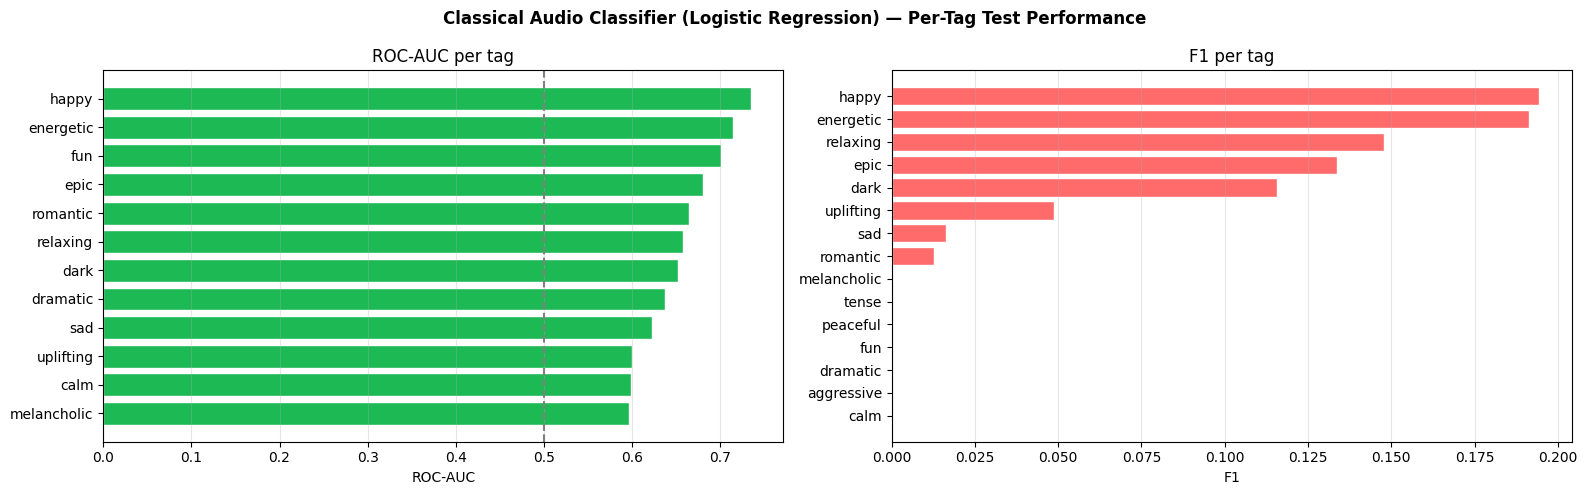

In [ ]:
# ── Per-tag breakdown ────────────────────────────────────────────────────────
probs_te_best = best_audio_clf.predict_proba(X_te_s)
preds_te_best = (probs_te_best >= 0.5).astype(int)

per_tag_auc = [roc_auc_score(Y_te[:,j], probs_te_best[:,j])
               if Y_te[:,j].sum()>0 else np.nan for j in range(N_MOODS)]
per_tag_f1  = f1_score(Y_te, preds_te_best, average=None, zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(16,5))
fig.suptitle(f"Classical Audio Classifier ({best_audio_name}) — Per-Tag Test Performance",
             fontweight="bold")
for ax, vals, label, colour in zip(
        axes, [per_tag_auc, per_tag_f1], ["ROC-AUC","F1"], ["#1DB954","#FF6B6B"]):
    order = np.argsort(vals)
    ax.barh([CFG["mood_tags"][i] for i in order],
            [vals[i] for i in order], color=colour, edgecolor="white")
    ax.set_title(f"{label} per tag"); ax.set_xlabel(label); ax.grid(axis="x", alpha=0.3)
    if label == "ROC-AUC":
        ax.axvline(0.5, color="gray", linestyle="--")
plt.tight_layout()
plt.savefig("audio_classifier_performance.png", dpi=150, bbox_inches="tight")
plt.show()


=== Naive Baseline — Test Set ===

  Affinity match: 620 / 1,911  (32.4%)


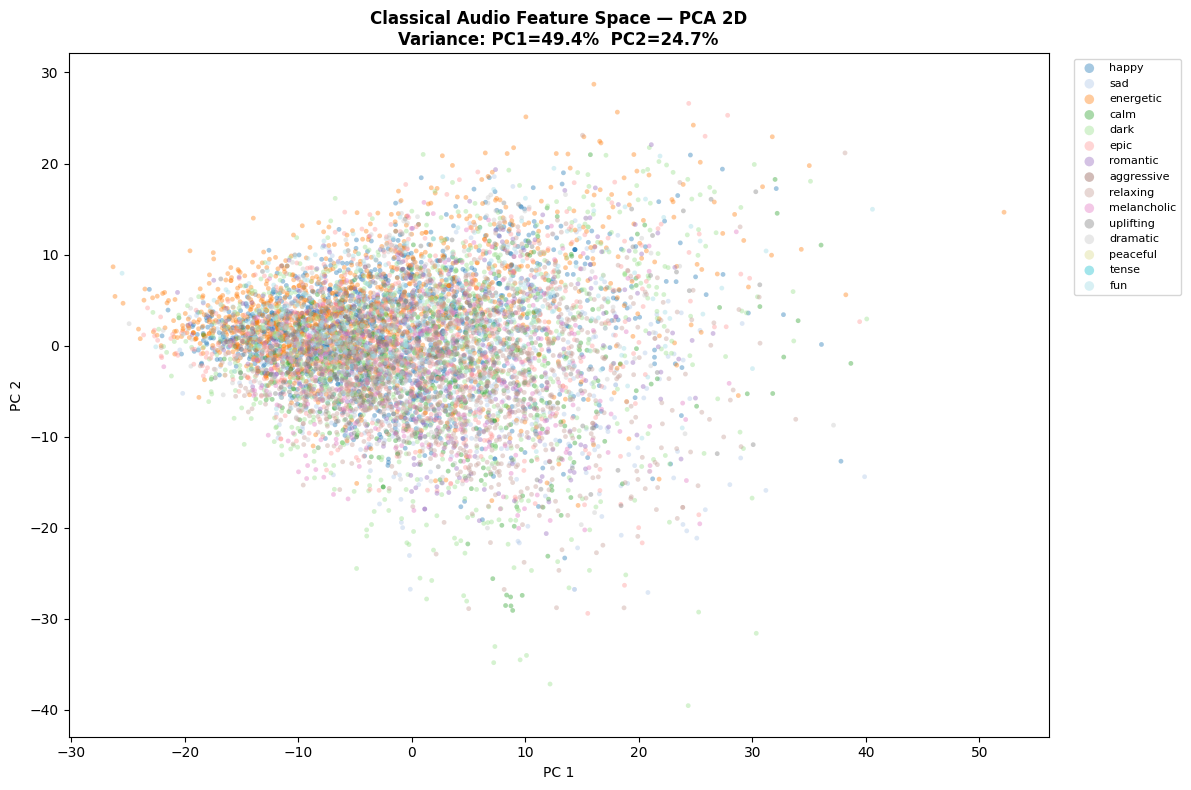

In [ ]:
# ── Naive baseline evaluation ─────────────────────────────────────────────────
test_df = df_all[test_mask_arr].reset_index(drop=True)
affinity_hits = sum(
    1 for _, r in test_df.iterrows()
    if any(t in BUCKET_AFFINITY.get(r["audio_bucket"],[]) for t in r["mood_tags"])
)
total = len(test_df)
print(f"=== Naive Baseline — Test Set ===\n")
print(f"  Affinity match: {affinity_hits:,} / {total:,}  ({affinity_hits/total:.1%})")

# ── PCA of audio feature space ────────────────────────────────────────────────
pca  = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_all_s)
primary_tags = [ts[0] if ts else "other" for ts in df_all["mood_tags"]]
palette = plt.cm.tab20(np.linspace(0,1,N_MOODS))
tag_color = dict(zip(CFG["mood_tags"], palette))

plt.figure(figsize=(12,8))
for tag in CFG["mood_tags"]:
    mask = [pt==tag for pt in primary_tags]
    pts  = X_2d[mask]
    plt.scatter(pts[:,0], pts[:,1], c=[tag_color[tag]], label=tag,
                alpha=0.4, s=12, edgecolors="none")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8, markerscale=2)
plt.title(
    f"Classical Audio Feature Space — PCA 2D\n"
    f"Variance: PC1={pca.explained_variance_ratio_[0]:.1%}  "
    f"PC2={pca.explained_variance_ratio_[1]:.1%}", fontweight="bold")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.tight_layout()
plt.savefig("audio_pca.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── Final comparison table ────────────────────────────────────────────────────
best_probs_te = best_audio_clf.predict_proba(X_te_s)
best_preds_te = (best_probs_te >= 0.5).astype(int)
auc_te = np.nanmean([roc_auc_score(Y_te[:,j], best_probs_te[:,j])
                     if Y_te[:,j].sum()>0 else np.nan for j in range(N_MOODS)])
pr_te  = np.nanmean([average_precision_score(Y_te[:,j], best_probs_te[:,j])
                     if Y_te[:,j].sum()>0 else np.nan for j in range(N_MOODS)])
f1_te  = f1_score(Y_te, best_preds_te, average="micro", zero_division=0)

print("\n" + "="*78)
print("  FINAL COMPARISON TABLE")
print("="*78)
rows = [
    ["Naive Baseline",
     "Energy/brightness rules","Color → mood bucket",
     f"{affinity_hits/total:.1%} affinity","N/A","N/A"],
    [f"Classical ({best_audio_name})",
     "261-d mel-band → OvR clf","CLIP → sklearn projection",
     f"{f1_te:.4f}",f"{auc_te:.4f}",f"{pr_te:.4f}"],
    ["Deep Learning (teammate)",
     "ResNet-18 on mel-specs","CLIP → MLP projection",
     "← fill from DL nb","← fill from DL nb","← fill from DL nb"],
]
header = ["Model","Audio side","Image side","micro-F1","AUC","PR-AUC"]
col_w  = [22,26,22,12,10,10]
print("  "+"  ".join(h.ljust(w) for h,w in zip(header,col_w)))
print("  "+"-"*(sum(col_w)+2*len(col_w)))
for row in rows:
    print("  "+"  ".join(str(v).ljust(w) for v,w in zip(row,col_w)))
print("="*78)
print("\n✅  Notebook complete.")



  FINAL COMPARISON TABLE
  Model                   Audio side                  Image side              micro-F1      AUC         PR-AUC    
  ------------------------------------------------------------------------------------------------------------------
  Naive Baseline          Energy/brightness rules     Color → mood bucket     32.4% affinity  N/A         N/A       
  Classical (Logistic Regression)  261-d mel-band → OvR clf    CLIP → sklearn projection  0.1108        0.6551      0.1687    
  Deep Learning (teammate)  ResNet-18 on mel-specs      CLIP → MLP projection   ← fill from DL nb  ← fill from DL nb  ← fill from DL nb

✅  Notebook complete.


## 6.1. Metrics Comparison (ROC-AUC, PR-AUC, BCE Loss)

In [ ]:
from sklearn.metrics import log_loss

def calculate_bce_loss(y_true, y_pred_proba):
    # Ensure y_pred_proba is clipped to avoid log(0)
    y_pred_proba = np.clip(y_pred_proba, 1e-15, 1 - 1e-15)
    return log_loss(y_true, y_pred_proba)

# Classical Model Metrics
bce_loss_classical = calculate_bce_loss(Y_te, best_probs_te)

print("\n=== Classical Model Metrics ===")
print(f"  ROC-AUC: {auc_te:.4f}")
print(f"  PR-AUC: {pr_te:.4f}")
print(f"  BCE Loss: {bce_loss_classical:.4f}")

print("\n=== Naive Baseline Metrics ===")
print(f"  Affinity Match: {affinity_hits/total:.1%}")
print("  ROC-AUC: N/A (rule-based)")
print("  PR-AUC: N/A (rule-based)")
print("  BCE Loss: N/A (rule-based)")


=== Classical Model Metrics ===
  ROC-AUC: 0.6551
  PR-AUC: 0.1687
  BCE Loss: 2.6389

=== Naive Baseline Metrics ===
  Affinity Match: 32.4%
  ROC-AUC: N/A (rule-based)
  PR-AUC: N/A (rule-based)
  BCE Loss: N/A (rule-based)


In [ ]:
# ── SAVE & DOWNLOAD ALL ARTIFACTS TO LOCAL ───────────────────────────────────
import os, shutil
import pickle
import numpy as np
from pathlib import Path
from google.colab import files

ARTIFACT_DIR = "/content/visual_vibe_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# ── Models ────────────────────────────────────────────────────────────────────
pickle.dump(best_audio_clf,  open(f"{ARTIFACT_DIR}/best_audio_clf.pkl",       "wb"))
pickle.dump(clip_projection, open(f"{ARTIFACT_DIR}/clip_mood_projection.pkl", "wb"))
pickle.dump(scaler,          open(f"{ARTIFACT_DIR}/audio_scaler.pkl",         "wb"))
pickle.dump(knn_mood,        open(f"{ARTIFACT_DIR}/knn_mood.pkl",             "wb"))
pickle.dump(mlb,             open(f"{ARTIFACT_DIR}/mlb.pkl",                  "wb"))
np.save(f"{ARTIFACT_DIR}/all_audio_mood_probs.npy", ALL_AUDIO_PROBS)

# ── Feature caches (if they exist) ───────────────────────────────────────────
for src in ["./data/embeddings/classical_features.npy",
            "./data/embeddings/naive_features.pkl",
            "./data/embeddings/melspec_clip_embeddings.npy"]:
    if Path(src).exists():
        shutil.copy(src, ARTIFACT_DIR)

# ── Evaluation results (if available) ────────────────────────────────────────
try:
    results_df.to_csv(f"{ARTIFACT_DIR}/eval_results.csv", index=False)
except NameError:
    pass

# ── Print sizes ───────────────────────────────────────────────────────────────
print("Artifacts:")
for f in sorted(Path(ARTIFACT_DIR).iterdir()):
    print(f"  {f.name:<42} {f.stat().st_size//1024} KB")

# ── Zip & download ────────────────────────────────────────────────────────────
shutil.make_archive("/content/visual_vibe_artifacts", "zip", ARTIFACT_DIR)
size_mb = Path("/content/visual_vibe_artifacts.zip").stat().st_size / 1e6
print(f"\n📦 Zipping {size_mb:.1f} MB...")
files.download("/content/visual_vibe_artifacts.zip")
print("✅ Downloading to your local Downloads folder")


Artifacts:
  all_audio_mood_probs.npy                   996 KB
  audio_scaler.pkl                           5 KB
  best_audio_clf.pkl                         24 KB
  classical_features.npy                     6545 KB
  clip_mood_projection.pkl                   32 KB
  knn_mood.pkl                               997 KB
  melspec_clip_embeddings.npy                17012 KB
  mlb.pkl                                    0 KB
  naive_features.pkl                         457 KB

📦 Zipping 7.9 MB...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloading to your local Downloads folder
